# Business Insights & Recommendations

## Objective

The objective of this notebook is to transform the analytical findings from the previous notebooks into meaningful business insights and strategic recommendations.

Using the results obtained through Exploratory Data Analysis (EDA) and Machine Learning, this notebook focuses on answering important business questions such as:

- Which products contribute the most to revenue?
- Which customer segments generate higher profits?
- Which regions require more attention?
- What are the major factors affecting sales performance?
- What business strategies can improve profitability?

The insights generated here can help business stakeholders make informed decisions regarding inventory management, marketing strategies, pricing, customer engagement, and overall business growth.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_palette("Set2")

In [2]:
df = pd.read_csv("cleaned_retail_sales.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'cleaned_retail_sales.csv'

In [3]:
import os

print(os.getcwd())

C:\Users\prave\anaconda_projects\a8481d99-7649-416e-82d6-a1655f339bb8


In [4]:
import os

for file in os.listdir():
    print(file)

.ipynb_checkpoints
02_Exploratory_Data_Analysis.ipynb
03_Machine_Learning.ipynb
03_Machine_Learning1.ipynb
04_Business_Insights_and_Recommendations.ipynb.ipynb
images


In [5]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\prave\OneDrive\Documents\AI-Retail-Sales-Analytics\data\raw\Sample - Superstore.csv",
    encoding="latin1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
total_sales = df["Sales"].sum()

print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,297,200.86


In [9]:
total_profit = df["Profit"].sum()

print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $286,397.02


In [10]:
total_orders = df["Order ID"].nunique()

print(f"Total Orders: {total_orders}")

Total Orders: 5009


total_customers = df["Customer ID"].nunique()

print(f"Total Customers: {total_customers}")

## Business Insight 1: Sales by Category

Understanding which product categories generate the highest revenue helps the business prioritize inventory, marketing campaigns, and future investments.

In [12]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

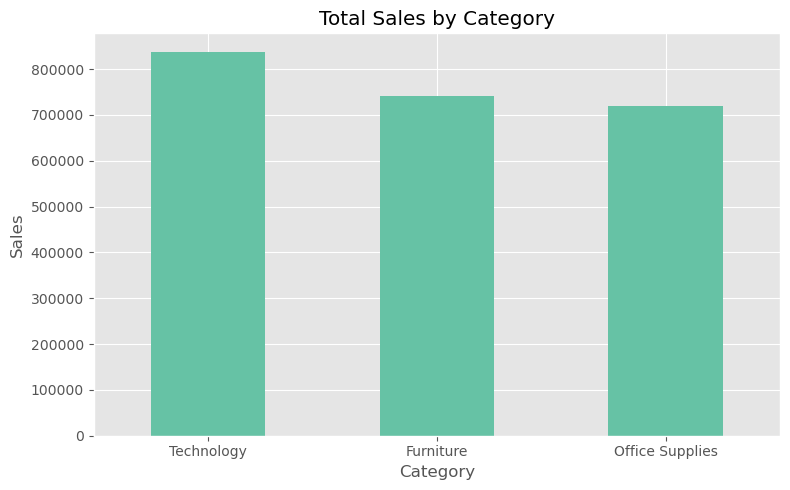

In [13]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Business Insight 2: Profit by Category

Revenue alone does not determine business success. Profit analysis helps identify which categories contribute the most to overall profitability.

In [14]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

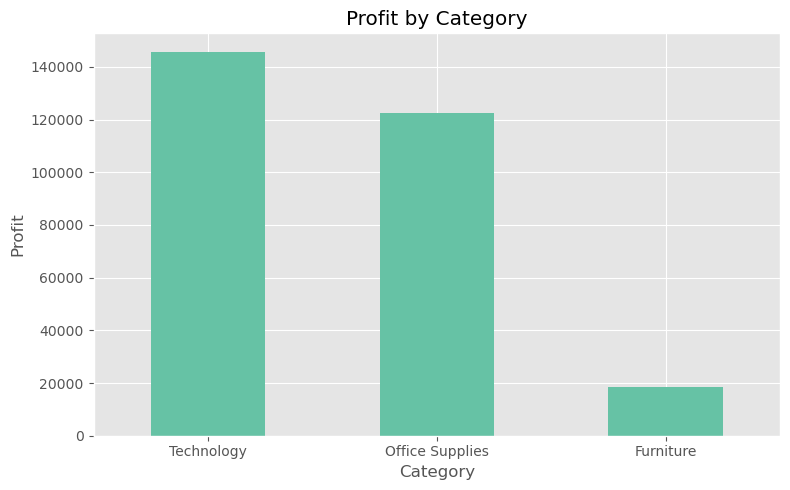

In [15]:
plt.figure(figsize=(8,5))

category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Business Insight 3: Sales by Region

Regional sales analysis helps identify high-performing markets and areas where additional marketing efforts or operational improvements may be required.

In [16]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

region_sales

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

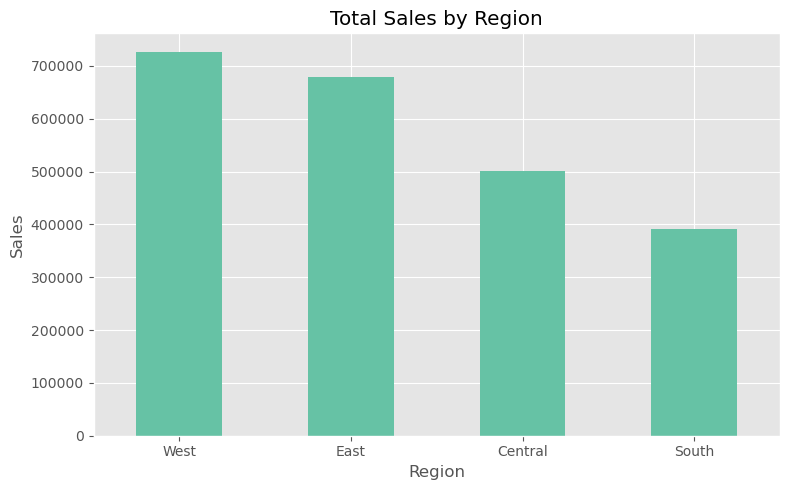

In [17]:
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Business Insight 4: Customer Segment Analysis

Customer segmentation helps identify which groups contribute the most revenue and profit. These insights support targeted marketing, customer retention strategies, and personalized business decisions.

In [18]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

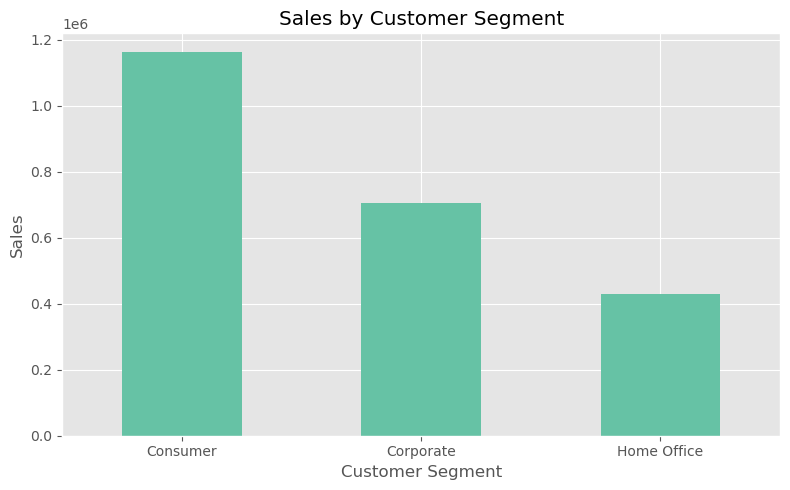

In [19]:
plt.figure(figsize=(8,5))

segment_sales.plot(kind="bar")

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [20]:
segment_profit = (
    df.groupby("Segment")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

segment_profit

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

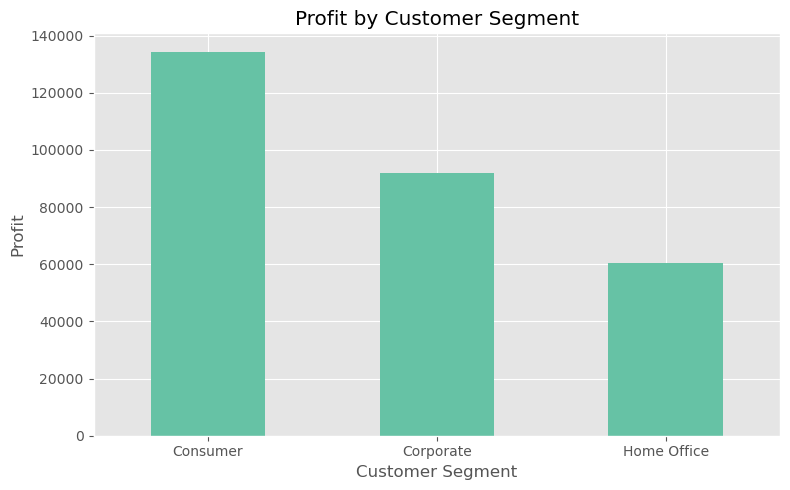

In [21]:
plt.figure(figsize=(8,5))

segment_profit.plot(kind="bar")

plt.title("Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Profit")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Business Insight

- Identify the customer segment contributing the highest sales and profit.
- Focus customer retention efforts on the highest-value segment.
- Develop targeted campaigns to improve engagement and revenue from lower-performing segments.

## Business Insight 5: Top 10 Products by Sales

Identifying the highest-selling products helps the business understand customer demand, optimize inventory levels, and prioritize products for marketing and promotional campaigns.

In [22]:
top_products_sales = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products_sales

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

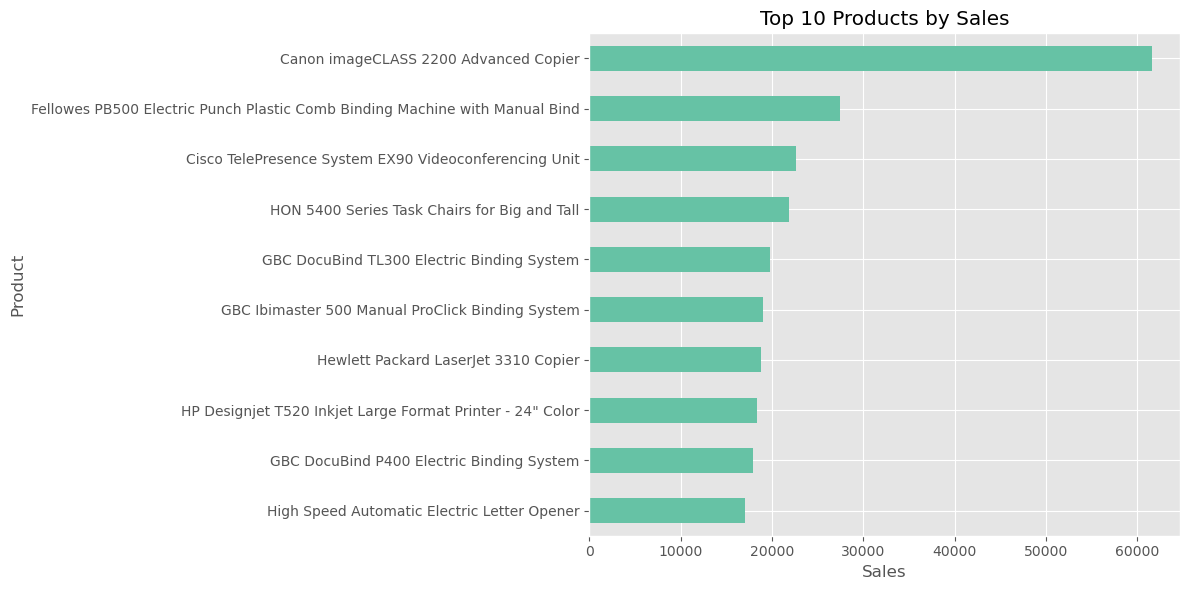

In [23]:
plt.figure(figsize=(12,6))

top_products_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### Business Insight

- The products with the highest sales should always be adequately stocked.
- These products can be highlighted in marketing campaigns and bundled with complementary products to increase overall sales.
- High-demand products should be monitored regularly to avoid stock shortages.

## Business Insight 6: Top 10 Products by Profit

Revenue does not always translate into profit. This analysis identifies the products that contribute the most to overall profitability.

In [24]:
top_products_profit = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products_profit

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

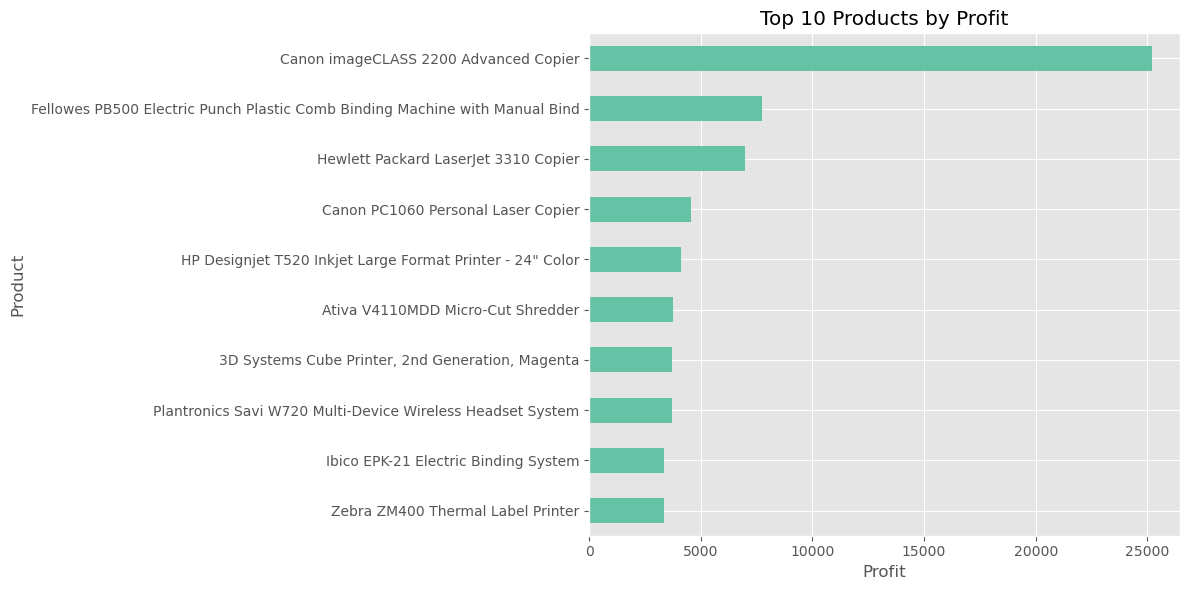

In [25]:
plt.figure(figsize=(12,6))

top_products_profit.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### Business Insight

- Products with the highest profit should receive greater marketing focus because they contribute significantly to business profitability.
- Comparing high-sales products with high-profit products helps identify items that generate strong revenue but lower margins.

## Business Insight 7: Sales by Sub-Category

Sub-category analysis provides more detailed insights than category-level analysis, helping identify the strongest-performing product groups.

In [26]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

subcategory_sales

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

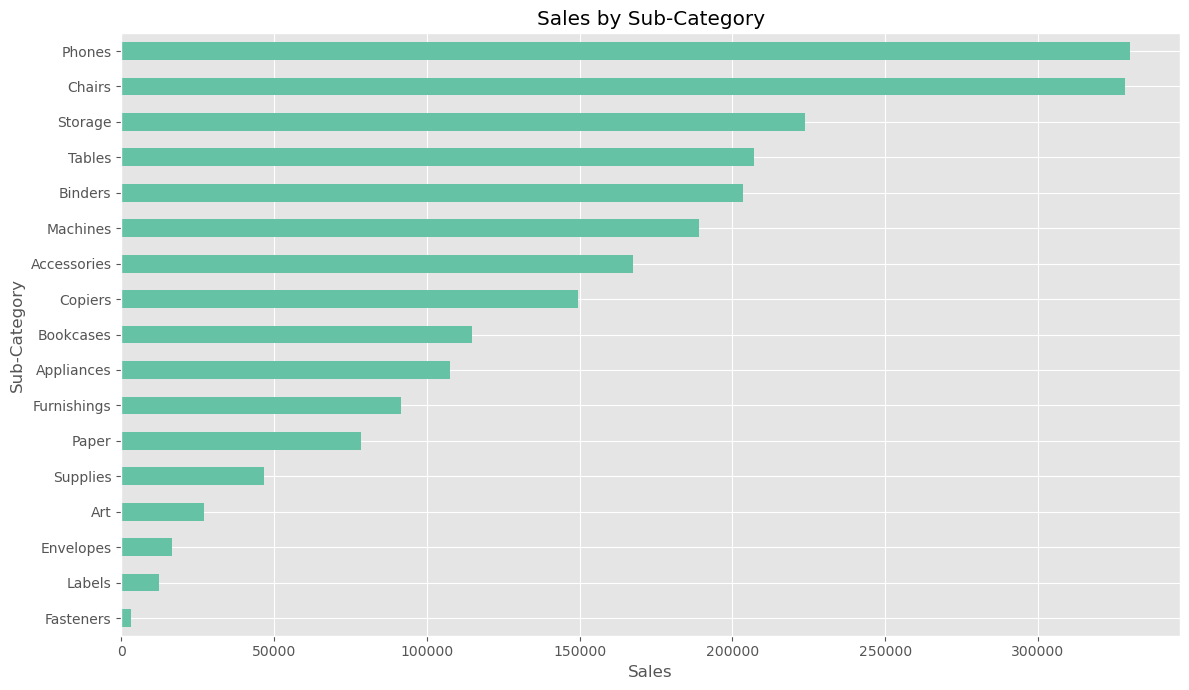

In [27]:
plt.figure(figsize=(12,7))

subcategory_sales.sort_values().plot(kind="barh")

plt.title("Sales by Sub-Category")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

### Business Insight

- High-performing sub-categories should receive continued investment in inventory and promotions.
- Lower-performing sub-categories should be reviewed to determine whether pricing, demand, or product assortment is affecting performance.

## Business Insight 8: Monthly Sales Trend

Understanding monthly sales trends helps businesses identify seasonal demand patterns, forecast future sales, and plan inventory and marketing campaigns more effectively.

In [28]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [29]:
df["Month-Year"] = df["Order Date"].dt.to_period("M").astype(str)

In [30]:
monthly_sales = (
    df.groupby("Month-Year")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Month-Year,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009
3,2014-04,28295.345
4,2014-05,23648.287


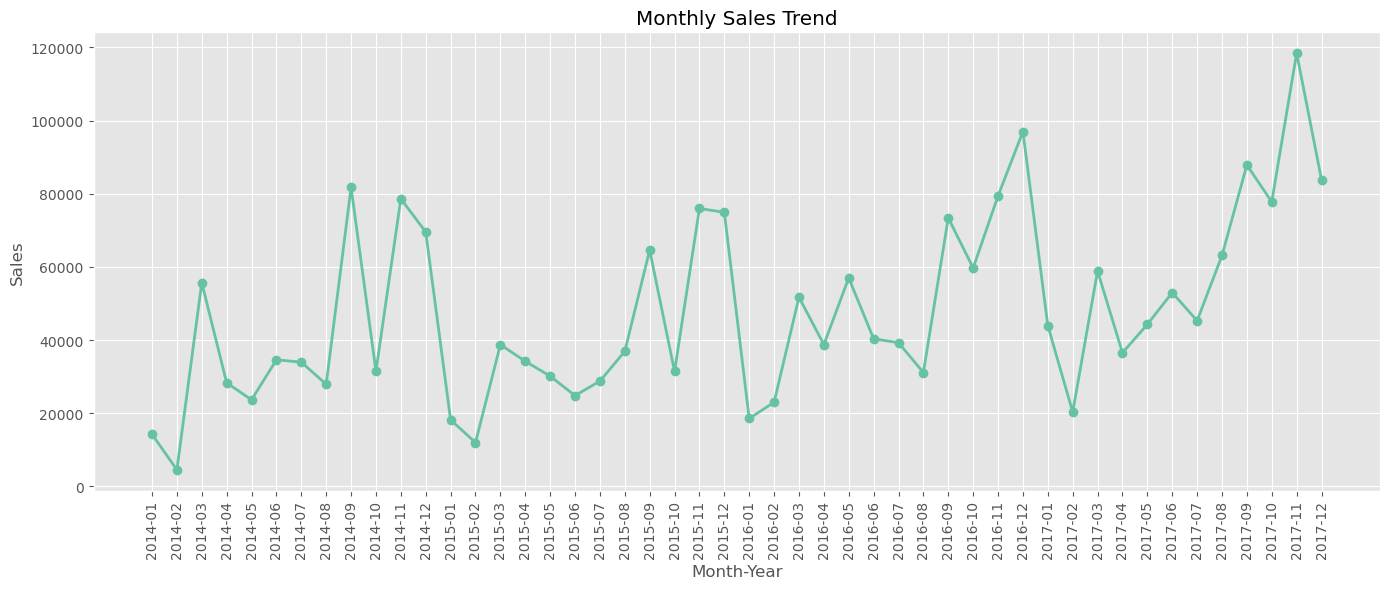

In [31]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Month-Year"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month-Year")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Business Insight

- Identify months with peak sales and periods of lower demand.
- Seasonal trends can help optimize inventory planning and marketing campaigns.
- Sales forecasting models can leverage these historical patterns for better business planning.

## Business Insight 9: Monthly Profit Trend

Monthly profit analysis helps evaluate whether increases in sales also translate into higher profitability.

In [32]:
monthly_profit = (
    df.groupby("Month-Year")["Profit"]
      .sum()
      .reset_index()
)

monthly_profit.head()

,Month-Year,Profit
0,2014-01,2450.1907
1,2014-02,862.3084
2,2014-03,498.7299
3,2014-04,3488.8352
4,2014-05,2738.7096


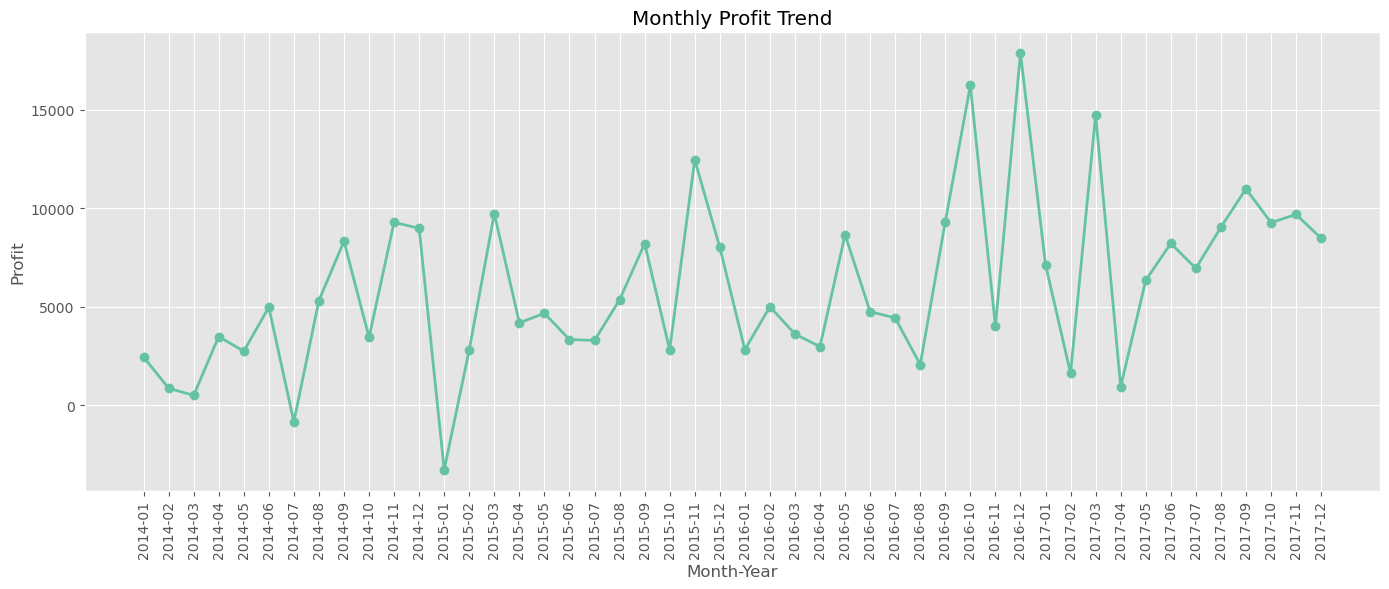

In [33]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_profit["Month-Year"],
    monthly_profit["Profit"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month-Year")
plt.ylabel("Profit")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Business Insight

- Compare sales and profit trends over time.
- Months with high sales but relatively low profit may indicate excessive discounts or higher operational costs.
- Understanding profit trends supports better financial planning and pricing strategies.

## Business Insight 10: Sales by Ship Mode

Shipping mode analysis helps evaluate customer preferences and the contribution of each shipping method to total sales.

In [34]:
shipmode_sales = (
    df.groupby("Ship Mode")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

shipmode_sales

Ship Mode
Standard Class    1.358216e+06
Second Class      4.591936e+05
First Class       3.514284e+05
Same Day          1.283631e+05
Name: Sales, dtype: float64

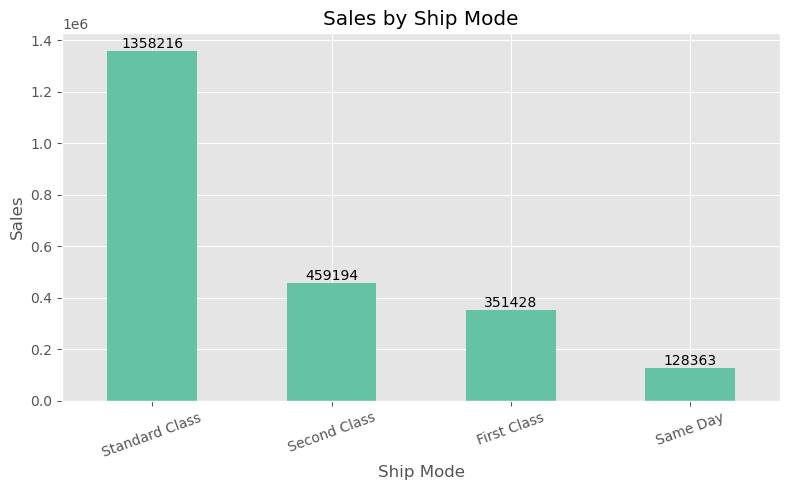

In [35]:
plt.figure(figsize=(8,5))

ax = shipmode_sales.plot(kind="bar")

plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Sales")
plt.xticks(rotation=20)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.tight_layout()
plt.show()

## Business Insight 11: Discount vs Profit

Discounts are often used to increase sales, but excessive discounts can reduce profitability. This analysis explores the relationship between discounts and profit.

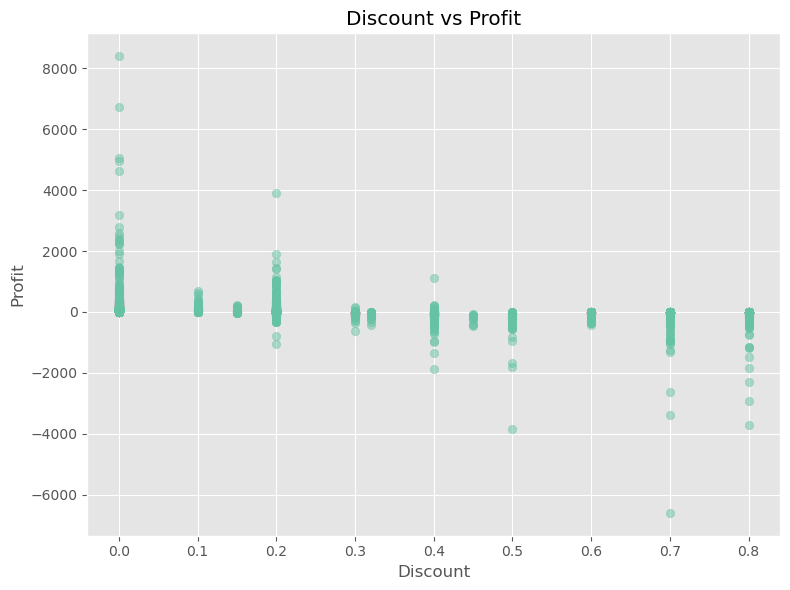

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.5
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

### Business Insight

- Higher discounts do not always lead to higher profits.
- Some highly discounted orders generate negative profits.
- Businesses should regularly review discount policies to balance sales growth with profitability.

# Executive Summary

## Key Findings

- Technology generated the highest overall profit.
- The West region recorded the highest sales performance.
- Customer segments contributed differently to revenue and profitability.
- A small number of products accounted for a significant share of total sales and profit.
- Monthly sales and profit trends revealed seasonal fluctuations.
- Higher discounts were associated with reduced profitability in many cases.

## Strategic Recommendations

1. Increase investment in high-profit product categories.
2. Optimize pricing strategies for low-margin products.
3. Expand marketing efforts in high-performing regions while improving performance in weaker regions.
4. Review discount policies to avoid unnecessary profit loss.
5. Improve inventory planning based on seasonal demand patterns.
6. Focus customer retention efforts on the highest-value customer segments.

## Conclusion

This analysis demonstrates how data analytics can support business decision-making by identifying revenue drivers, profitability trends, customer behavior, and operational improvement opportunities. The insights can help organizations make informed strategic decisions that improve both customer satisfaction and overall business performance.